# LIBRISPEECH


datasets è una libreria che fornisce un'interfaccia semplice per accedere a vari dataset, tra cui LibriSpeech. Librosa è una libreria per l'analisi audio e la visualizzazione, mentre Matplotlib è utilizzata per creare grafici e visualizzazioni. NumPy è una libreria fondamentale per il calcolo scientifico in Python.

In [1]:
import datasets
import librosa
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd
import io
import pandas as pd

/opt/miniconda3/envs/tirocinio/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ora bisogna connettersi al dataset LibriSpeech e caricare un esempio di audio. Utilizziamo la modalità di streaming per accedere ai dati senza doverli scaricare completamente.


In [3]:
print("Connessione a librispeech...")
ds = datasets.load_dataset("librispeech_asr", "clean", split="validation", streaming=True)
ds = ds.cast_column("audio", datasets.Audio(decode=False))
example = next(iter(ds))
print("Caricato!")
print(example.keys())

Connessione a librispeech...
Caricato!
dict_keys(['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id'])


In [6]:
audio_bytes = example["audio"]["bytes"]
audio_path  = example["audio"]["path"]

In [ ]:
audio_array, sr = librosa.load(io.BytesIO(audio_bytes), sr=None)
ipd.Audio(audio_array, rate=sr)
audio_array[0:10]


Transcription:HE WAS IN A FEVERED STATE OF MIND OWING TO THE BLIGHT HIS WIFE'S ACTION THREATENED TO CAST UPON HIS ENTIRE FUTURE


Text(0.5, 1.0, 'Onda del segnale audio')

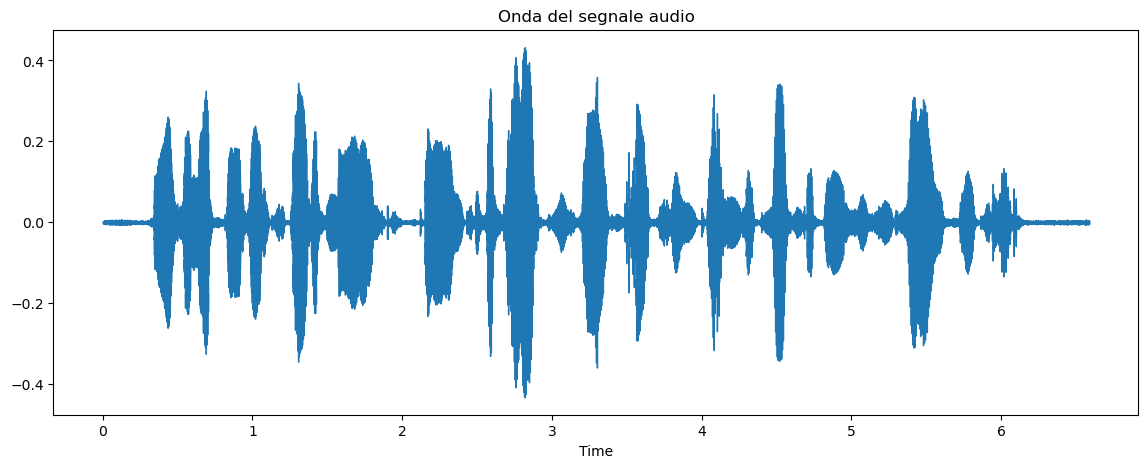

In [11]:
print("Transcription:" + example["text"])
plt.figure(figsize=(14, 5))
librosa.display.waveshow(audio_array, sr=sr)
plt.title("Onda del segnale audio")

Ora passo a fare lo spettrogramma:

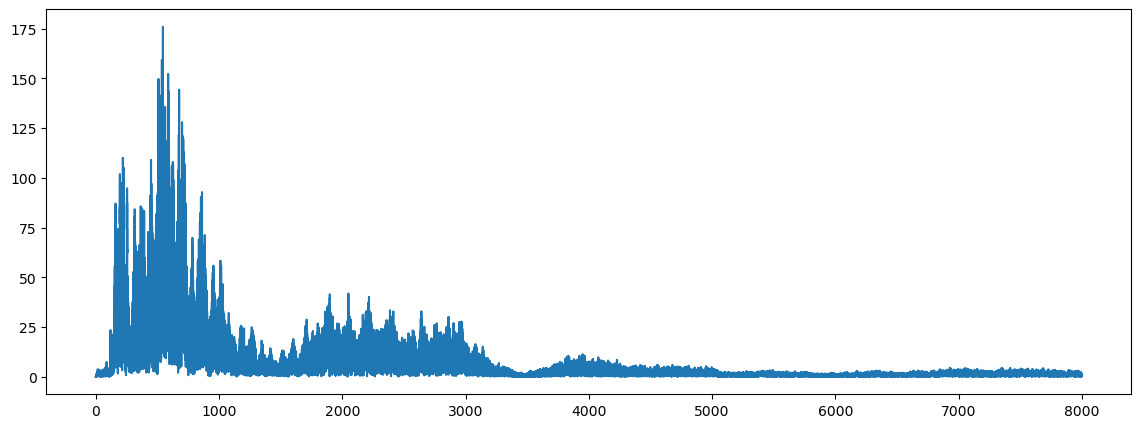

In [13]:
fft_values = np.fft.fft(audio_array)

magnitude = np.abs(fft_values)

frequencies = np.fft.fftfreq(len(fft_values), 1/sr)

p_frequencies = frequencies[:len(frequencies)//2]
p_magnitude = magnitude[:len(magnitude)//2]


plt.figure(figsize=(14, 5))
plt.plot(p_frequencies, p_magnitude)

Ora faccio la stft:

Forma STFT: (257, 660)
Bin di frequenza: 257
Frame temporali: 660


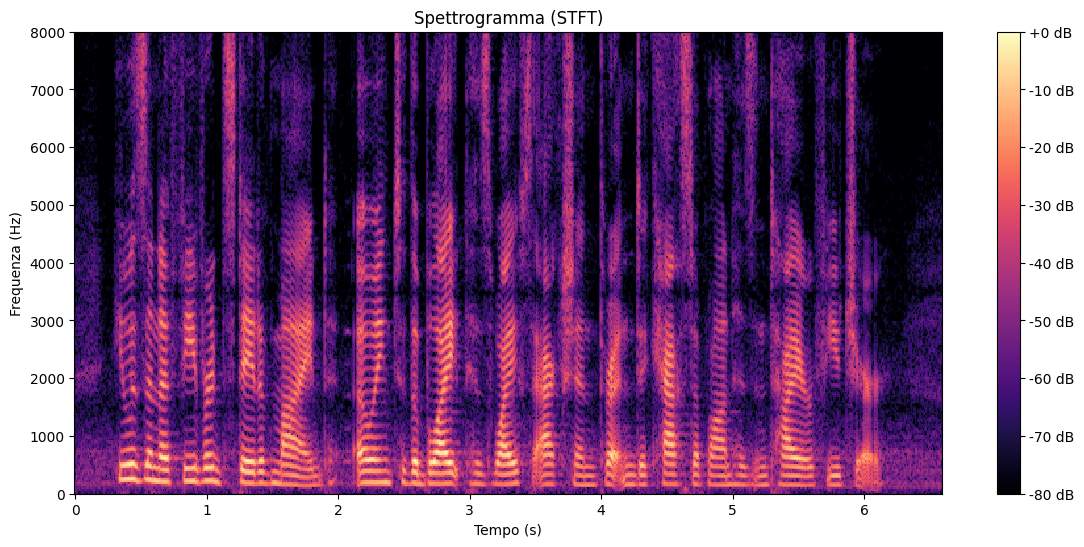

In [ ]:
n_fft = 512
hop_length = 160

D = librosa.stft(audio_array, n_fft=n_fft, hop_length=hop_length)

magnitude_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

print(f"Forma STFT: {D.shape}")
print(f"Bin di frequenza: {D.shape[0]}")
print(f"Frame temporali: {D.shape[1]}")
plt.figure(figsize=(14, 6))
librosa.display.specshow(magnitude_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spettrogramma (STFT)')
plt.xlabel('Tempo (s)')
plt.ylabel('Frequenza (Hz)')
plt.ylim(0, 8000)
plt.show()